In [1]:
import torch
from torchviz import make_dot

In [2]:
#criando dois conjuntos de dados, onde o conjunto y representa a soma dos conjuntos em x
x = [[1,2],[3,4],[5,6],[7,8]]
y = [[3],[7],[11],[15]]

In [3]:
#convertendo os dados para tensores

X = torch.tensor(x).float()
Y = torch.tensor(y).float()

In [4]:
#verificando se a gpu está disponível

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [5]:
#configurando os tensores x e y para a gpu

X = X.to(device)
Y = Y.to(device)

In [6]:
import torch.nn as nn

In [7]:
#criando a rede neural

class MyNeuralNet(nn.Module):
  def __init__(self):    
    super().__init__()
    self.layer1 = nn.Linear(2,8)
    self.activation = nn.ReLU()
    self.layer2 =  nn.Linear(8,1)

  def forward(self,x):
    x = self.layer1(x)
    x = self.activation(x)
    x = self.layer2(x)
    return x

In [8]:
#criando o modelo e configurando-o para a gpu

model = MyNeuralNet()
model.to(device)

MyNeuralNet(
  (layer1): Linear(in_features=2, out_features=8, bias=True)
  (activation): ReLU()
  (layer2): Linear(in_features=8, out_features=1, bias=True)
)

In [9]:
#função para visualizar o modelo

make_dot(model(X), params=dict(model.named_parameters())).render("dense_network", format="png")

'dense_network.png'

In [10]:
X.shape

torch.Size([4, 2])

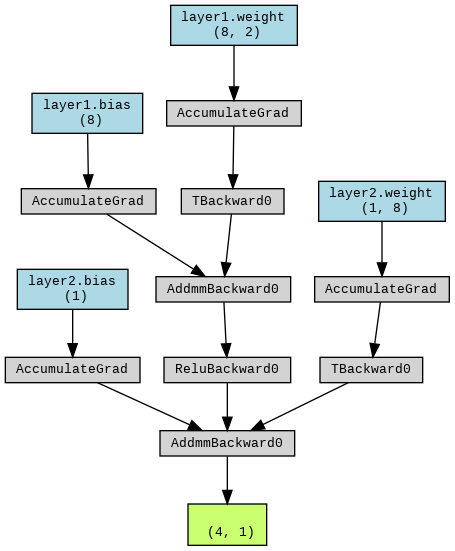

In [11]:
model.layer1.weight

Parameter containing:
tensor([[ 0.4173, -0.6203],
        [ 0.1567,  0.4882],
        [-0.1153,  0.3310],
        [ 0.5198, -0.5343],
        [-0.4035,  0.2497],
        [-0.1848, -0.0833],
        [-0.3392, -0.4347],
        [-0.6026, -0.0948]], device='cuda:0', requires_grad=True)

In [12]:
model.parameters().__next__()

Parameter containing:
tensor([[ 0.4173, -0.6203],
        [ 0.1567,  0.4882],
        [-0.1153,  0.3310],
        [ 0.5198, -0.5343],
        [-0.4035,  0.2497],
        [-0.1848, -0.0833],
        [-0.3392, -0.4347],
        [-0.6026, -0.0948]], device='cuda:0', requires_grad=True)